# BiLSTM-GRU

**Модель:** BiLSTM → GRU → mean pooling → FC + SpecAugment

In [1]:
import sys
from pathlib import Path
import numpy as np
import time
from joblib import Parallel, delayed
import mlflow
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score as _f1
import matplotlib.pyplot as plt

exp_dir = Path().resolve()
sys.path.insert(0, str(exp_dir.parent.parent))
sys.path.insert(0, str(exp_dir))

from shared import config, data_utils, train_utils
from shared.evaluate import find_optimal_threshold, evaluate
from shared.results_utils import save_result_csv
from shared.mlflow_utils import start_run, log_epoch, log_artifact_if_exists
from model import get_model

train_utils.set_seed(config.RANDOM_STATE)

/home/dk/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
(
    paths_trainval, labels_trainval, letters_trainval,
    paths_test, labels_test, letters_test,
) = data_utils.get_holdout_split()

idx = np.arange(len(paths_trainval))
idx_tr, idx_val = train_test_split(
    idx, test_size=0.18, stratify=labels_trainval, random_state=config.RANDOM_STATE
)
paths_train,   paths_val   = paths_trainval[idx_tr],   paths_trainval[idx_val]
labels_train,  labels_val  = labels_trainval[idx_tr],  labels_trainval[idx_val]
letters_train, letters_val = letters_trainval[idx_tr], letters_trainval[idx_val]

In [3]:
N_MELS, N_FRAMES = config.N_MELS, 320

def load_mel(path):
    return data_utils.extract_mel_spectrogram(path, max_frames=N_FRAMES)

print("Mel...")
X_train = np.stack(Parallel(n_jobs=-1)(delayed(load_mel)(p) for p in paths_train))
X_val   = np.stack(Parallel(n_jobs=-1)(delayed(load_mel)(p) for p in paths_val))
X_test  = np.stack(Parallel(n_jobs=-1)(delayed(load_mel)(p) for p in paths_test))

mel_mean = X_train.mean(axis=(0, 2), keepdims=True)
mel_std  = np.where(X_train.std(axis=(0, 2), keepdims=True) < 1e-6, 1.0,
                    X_train.std(axis=(0, 2), keepdims=True))
X_train = (X_train - mel_mean) / mel_std
X_val   = (X_val   - mel_mean) / mel_std
X_test  = (X_test  - mel_mean) / mel_std
# (N, N_MELS, T) → (N, T, N_MELS) для LSTM
X_train = X_train.transpose(0, 2, 1)
X_val   = X_val.transpose(0, 2, 1)
X_test  = X_test.transpose(0, 2, 1)

Mel...


In [4]:
class MelSeqDataset(Dataset):
    def __init__(self, X, letters, labels, augment=False):
        self.X, self.letters, self.labels, self.augment = X, letters, labels, augment
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        x = self.X[i].copy()
        if self.augment:
            x = data_utils.augment_mel_spectrogram(x.T).T
        return torch.from_numpy(x).float(), torch.from_numpy(self.letters[i]).float(), int(self.labels[i])

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
BATCH = 32
train_loader = DataLoader(MelSeqDataset(X_train, letters_train, labels_train, augment=True),  batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(MelSeqDataset(X_val,   letters_val,   labels_val,   augment=False), batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(MelSeqDataset(X_test,  letters_test,  labels_test,  augment=False), batch_size=BATCH, shuffle=False)

Epoch 1/60  loss=0.6502  val_f1=0.6624
Epoch 2/60  loss=0.6231  val_f1=0.6743
Epoch 3/60  loss=0.6159  val_f1=0.6906
Epoch 4/60  loss=0.6045  val_f1=0.6482
Epoch 5/60  loss=0.6156  val_f1=0.6776
Epoch 6/60  loss=0.6058  val_f1=0.6743
Epoch 7/60  loss=0.5915  val_f1=0.7055
Epoch 8/60  loss=0.5874  val_f1=0.6912
Epoch 9/60  loss=0.5873  val_f1=0.6897
Epoch 10/60  loss=0.5783  val_f1=0.6930
Epoch 11/60  loss=0.5717  val_f1=0.6915
Epoch 12/60  loss=0.5705  val_f1=0.7042
Epoch 13/60  loss=0.5590  val_f1=0.6948
Epoch 14/60  loss=0.5429  val_f1=0.7164
Epoch 15/60  loss=0.5401  val_f1=0.7028
Epoch 16/60  loss=0.5463  val_f1=0.6984
Epoch 17/60  loss=0.5388  val_f1=0.7060
Epoch 18/60  loss=0.5335  val_f1=0.6993
Epoch 19/60  loss=0.5334  val_f1=0.7106
Epoch 20/60  loss=0.5203  val_f1=0.7042
Epoch 21/60  loss=0.5118  val_f1=0.7209
Epoch 22/60  loss=0.4992  val_f1=0.7178
Epoch 23/60  loss=0.4988  val_f1=0.6975
Epoch 24/60  loss=0.4962  val_f1=0.7285
Epoch 25/60  loss=0.4907  val_f1=0.7092
Epoch 26/

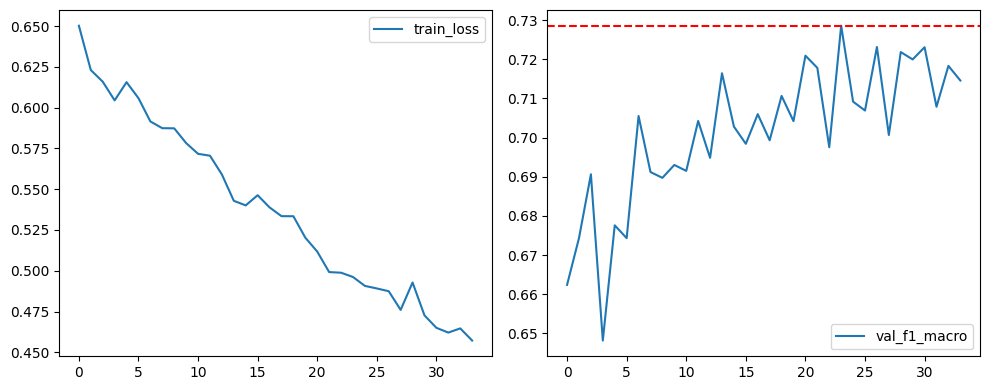

Результаты сохранены


In [5]:
n_letters = letters_train.shape[1]
N_EPOCHS, LSTM_H, GRU_H, DROPOUT = 60, 128, 64, 0.3

with start_run("exp_bilstm_gru", group="02_spectrogram_models"):

    mlflow.log_params({
        "model": "BiLSTM-GRU", "n_mels": N_MELS, "n_frames": N_FRAMES,
        "lstm_hidden": LSTM_H, "gru_hidden": GRU_H, "dropout": DROPOUT,
        "augment": "SpecAugment", "n_epochs": N_EPOCHS,
        "optimizer": "AdamW", "lr": 1e-3,
    })

    model = get_model(input_size=N_MELS, num_classes=2, lstm_hidden=LSTM_H,
                      gru_hidden=GRU_H, n_letters=n_letters, dropout=DROPOUT).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    mlflow.log_param("num_params", n_params)

    weights = compute_class_weight("balanced", classes=np.unique(labels_train), y=labels_train)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = train_utils.get_lr_scheduler(optimizer)
    early_stopping = train_utils.EarlyStopping(patience=config.EARLY_STOPPING_PATIENCE)
    best_ckpt, best_f1 = exp_dir / "best_ckpt.pt", -1.0

    def eval_loader(loader):
        model.eval()
        logits_list, true_list = [], []
        with torch.no_grad():
            for x, letters, y in loader:
                logits_list.append(model(x.to(device), letters.to(device)).cpu().numpy())
                true_list.extend(y.tolist())
        logits = np.concatenate(logits_list)
        proba  = torch.softmax(torch.from_numpy(logits), dim=1).numpy()[:, config.CLASS_BAD]
        return proba, np.array(true_list)

    train_losses, val_f1s = [], []
    t0 = time.perf_counter()

    for epoch in range(N_EPOCHS):
        model.train()
        losses = []
        for x, letters, y in train_loader:
            x, letters, y = x.to(device), letters.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x, letters), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.DEFAULT_GRAD_CLIP)
            optimizer.step()
            losses.append(loss.item())
        train_loss = np.mean(losses)
        train_losses.append(train_loss)

        val_proba, val_true = eval_loader(val_loader)
        val_f1 = _f1(val_true, (val_proba >= 0.5).astype(int), average="macro")
        val_f1s.append(val_f1)

        log_epoch(epoch, train_loss=train_loss, val_f1_macro=val_f1,
                  lr=optimizer.param_groups[0]["lr"])

        if val_f1 > best_f1:
            best_f1 = val_f1
            train_utils.save_best_checkpoint(model, best_ckpt)
        scheduler.step(val_f1)
        print(f"Epoch {epoch+1}/{N_EPOCHS}  loss={train_loss:.4f}  val_f1={val_f1:.4f}")
        if early_stopping.step(val_f1):
            print(f"Early stopping на эпохе {epoch+1}")
            break

    train_time_sec = time.perf_counter() - t0
    train_utils.load_best_checkpoint(model, best_ckpt, device)

    val_proba, val_true = eval_loader(val_loader)
    optimal_threshold = find_optimal_threshold(val_true, val_proba)
    test_proba, test_true = eval_loader(test_loader)
    test_metrics = evaluate(test_true, test_proba, threshold=optimal_threshold, verbose=True)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(train_losses, label="train_loss"); axes[0].legend()
    axes[1].plot(val_f1s, label="val_f1_macro")
    axes[1].axhline(best_f1, color="r", linestyle="--"); axes[1].legend()
    plt.tight_layout()
    fig.savefig(exp_dir / "training_curves.png", dpi=120)
    plt.show()

    save_result_csv(
        exp_dir=exp_dir, experiment_id="exp_bilstm_gru",
        experiment_name="BiLSTM-GRU на log-mel + SpecAugment",
        model="BiLSTM-GRU",
        accuracy=test_metrics["accuracy"], f1_macro=test_metrics["f1_macro"],
        f1_bad=test_metrics["f1_bad"],     roc_auc=test_metrics["roc_auc"],
        precision_bad=test_metrics["precision_bad"], recall_bad=test_metrics["recall_bad"],
        threshold=test_metrics["threshold"],
        embed_dim=64,
        embed_dim_note="BiLSTM(128) → GRU(64, unidirec.), mean pooling → fc=Linear(64+n_letters)",
        notes=f"SpecAugment + holdout | thr={optimal_threshold:.2f}",
        num_params=n_params, train_time_sec=train_time_sec,
    )
    log_artifact_if_exists(exp_dir / "training_curves.png")
    print("Результаты сохранены")